In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from sklearn.cluster import KMeans, DBSCAN    
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../datasets/superstore.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   object 
 2   order_date     9994 non-null   object 
 3   ship_date      9994 non-null   object 
 4   ship_mode      9994 non-null   object 
 5   customer_id    9994 non-null   object 
 6   customer_name  9994 non-null   object 
 7   segment        9994 non-null   object 
 8   country        9994 non-null   object 
 9   city           9994 non-null   object 
 10  state          9994 non-null   object 
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   object 
 13  product_id     9994 non-null   object 
 14  category       9994 non-null   object 
 15  sub-category   9994 non-null   object 
 16  product_name   9994 non-null   object 
 17  sales          9994 non-null   float64
 18  quantity

In [5]:
df["postal_code"] = df["postal_code"].astype(str)
df["row_id"] = df["row_id"].astype(str)

df["order_date"] = pd.to_datetime(df["order_date"], format='%m/%d/%Y')
df["ship_date"] = pd.to_datetime(df["ship_date"], format='%m/%d/%Y')

In [6]:
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.to_period("M")
df["order_month_name"] = (df["order_date"].dt.month_name())
df["order_day"] = (df["order_date"].dt.day_name())

In [7]:
df.rename(columns={"sales" : "revenue"}, inplace=True)

In [8]:
df.loc[df["order_date"] > df["ship_date"]]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,revenue,quantity,discount,profit,order_year,order_month,order_month_name,order_day


In [9]:
snapshot_date = df["order_date"].max() +  dt.timedelta(days=1)
snapshot_date

Timestamp('2017-12-31 00:00:00')

In [10]:
rfm = df.groupby("customer_id").agg({"order_date" : "max", "order_id" : "nunique", "revenue" : "sum"})
rfm

,order_date,order_id,revenue
customer_id,,,
AA-10315,2017-06-29,5,5563.560
AA-10375,2017-12-11,9,1056.390
AA-10480,2017-04-15,4,1790.512
AA-10645,2017-11-05,6,5086.935
AB-10015,2016-11-10,3,886.156
...,...,...,...
XP-21865,2017-11-17,11,2374.658
YC-21895,2017-12-26,5,5454.350
YS-21880,2017-12-21,8,6720.444


In [11]:
rfm.columns = ["last_purchase", "frequency", "monetary"]
rfm

,last_purchase,frequency,monetary
customer_id,,,
AA-10315,2017-06-29,5,5563.560
AA-10375,2017-12-11,9,1056.390
AA-10480,2017-04-15,4,1790.512
AA-10645,2017-11-05,6,5086.935
AB-10015,2016-11-10,3,886.156
...,...,...,...
XP-21865,2017-11-17,11,2374.658
YC-21895,2017-12-26,5,5454.350
YS-21880,2017-12-21,8,6720.444


In [12]:
rfm["recency"] = (snapshot_date - rfm["last_purchase"]).dt.days
rfm.drop(columns="last_purchase", inplace=True)

In [13]:
rfm

,frequency,monetary,recency
customer_id,,,
AA-10315,5,5563.560,185
AA-10375,9,1056.390,20
AA-10480,4,1790.512,260
AA-10645,6,5086.935,56
AB-10015,3,886.156,416
...,...,...,...
XP-21865,11,2374.658,44
YC-21895,5,5454.350,5
YS-21880,8,6720.444,10


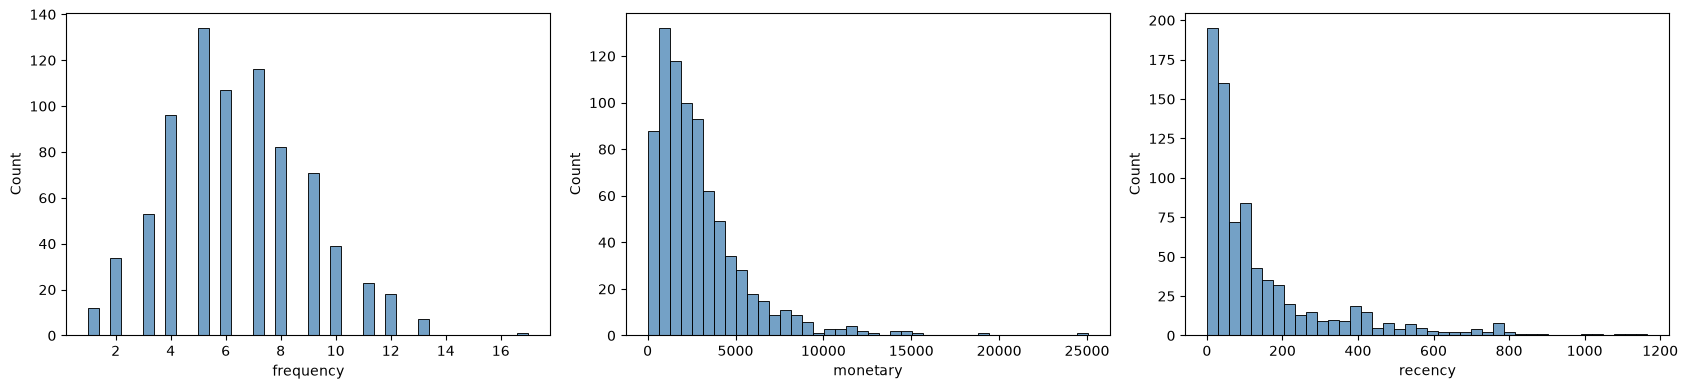

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
for i, col in enumerate(rfm.columns):
    sns.histplot(data=rfm, x=col, ax=ax[i], color="steelblue", edgecolor="black", bins=40)
plt.tight_layout(); plt.show()

In [15]:
rfm.skew()

frequency    0.362409
monetary     2.476555
recency      2.276395
dtype: float64

In [16]:
rfm_log = np.log(rfm)
rfm_log.skew()

frequency   -1.039098
monetary    -1.321134
recency     -0.383143
dtype: float64

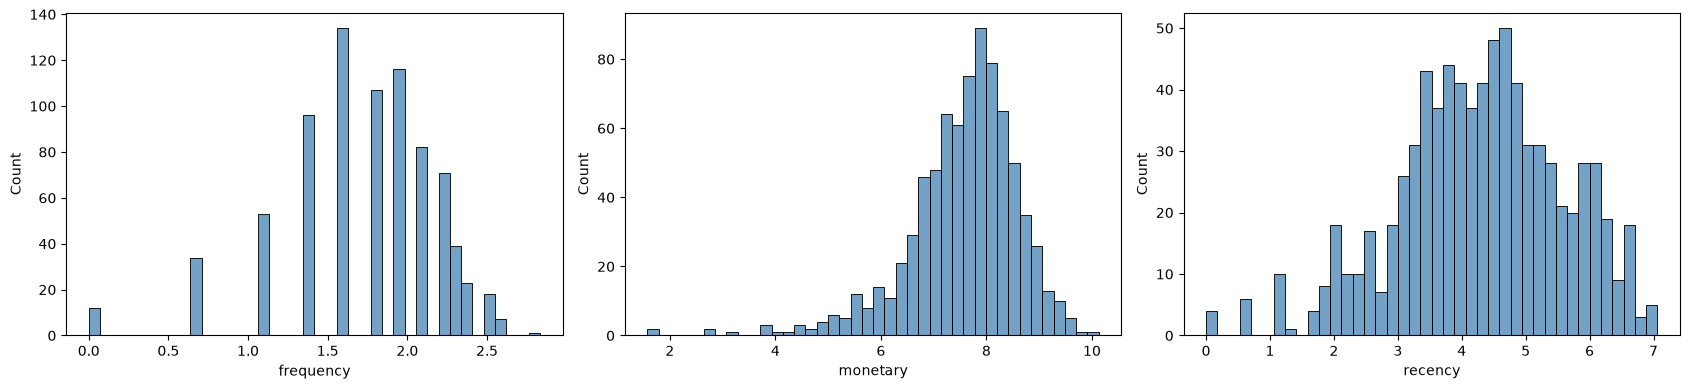

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
for i, col in enumerate(rfm_log.columns):
    sns.histplot(data=rfm_log, x=col, ax=ax[i], color="steelblue", edgecolor="black", bins=40)
plt.tight_layout(); plt.show()

In [18]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [19]:
inertia=[]
for k in range(1,11):
    model_km = KMeans(n_clusters=k, random_state=42)
    model_km.fit(rfm_scaled)
    inertia.append(model_km.inertia_)
inertia

  File "d:\data-analysis-notes\data-analysis-notes\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "d:\data-analysis-notes\data-analysis-notes\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Python314\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python314\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umas

[2379.0000000000005,
 1497.810025903091,
 1184.8735885991837,
 986.8423242324138,
 862.3381967408704,
 768.2141486450515,
 706.8209462581372,
 650.2997591438732,
 598.3001054850829,
 561.3147997091394]

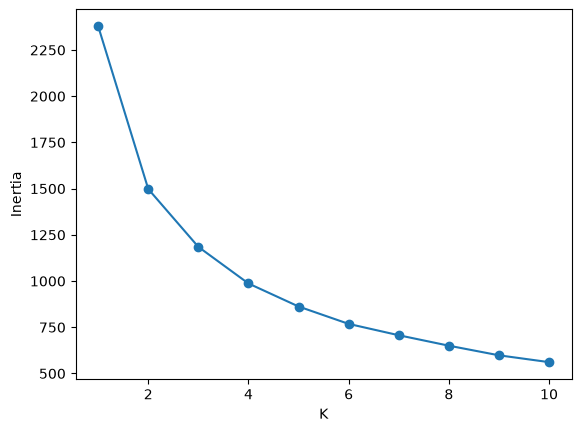

In [20]:
plt.plot(range(1, len(inertia) + 1), inertia, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [21]:
km_model = KMeans(n_clusters=4, random_state=23, init="k-means++", max_iter=300)
cat = km_model.fit_predict(rfm_scaled)
cat

array([1, 3, 1, 0, 2, 0, 0, 1, 3, 1, 1, 2, 3, 3, 1, 0, 3, 1, 1, 2, 3, 2,
       0, 1, 0, 2, 0, 3, 0, 0, 1, 3, 1, 3, 0, 3, 0, 0, 1, 2, 3, 0, 2, 3,
       0, 1, 1, 3, 3, 2, 0, 0, 0, 2, 3, 1, 3, 1, 3, 3, 3, 0, 3, 1, 1, 0,
       0, 0, 0, 2, 0, 1, 3, 1, 1, 1, 1, 1, 1, 1, 0, 2, 0, 1, 2, 0, 3, 1,
       0, 1, 1, 1, 0, 1, 2, 3, 1, 2, 1, 3, 1, 3, 3, 3, 1, 3, 3, 1, 3, 2,
       1, 1, 1, 2, 1, 3, 1, 2, 0, 1, 0, 1, 0, 3, 0, 0, 3, 0, 1, 0, 0, 0,
       3, 0, 2, 3, 3, 1, 3, 2, 2, 1, 1, 1, 1, 2, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 2, 3, 3, 3, 1, 0, 2, 0, 1, 0, 0, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0,
       3, 3, 2, 1, 0, 0, 1, 3, 3, 0, 1, 2, 3, 1, 3, 0, 3, 0, 1, 1, 0, 3,
       3, 0, 3, 1, 1, 1, 3, 1, 1, 1, 0, 3, 0, 0, 3, 0, 2, 3, 3, 1, 0, 3,
       1, 0, 1, 0, 0, 1, 1, 1, 3, 1, 3, 2, 0, 3, 0, 1, 3, 3, 3, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 3, 1, 1, 1, 0, 3, 0, 1, 1, 3, 0, 1, 1,
       1, 1, 2, 1, 0, 1, 2, 1, 0, 2, 1, 0, 1, 3, 0, 0, 0, 0, 3, 0, 1, 3,
       3, 0, 0, 0, 0, 2, 0, 3, 0, 3, 3, 0, 0, 1, 2,

In [22]:
silhouette_scores_km = silhouette_samples(rfm_scaled, cat)
pd.Series(silhouette_scores_km).groupby(cat).describe()

,count,mean,std,min,25%,50%,75%,max
0,250.0,0.325243,0.122674,0.057353,0.241598,0.331934,0.421300,0.545507
1,272.0,0.265106,0.156024,-0.072226,0.145206,0.283872,0.391680,0.509600
2,90.0,0.151239,0.168413,-0.199547,0.005399,0.158686,0.297756,0.409157
3,181.0,0.187760,0.145000,-0.081364,0.072256,0.179670,0.322512,0.442828


In [23]:
rfm_scaled

array([[-0.28978131,  1.01042898,  0.72283145],
       [ 0.95296604, -0.56524536, -0.97663758],
       [-0.76156993, -0.06482101,  0.98281843],
       ...,
       [ 0.70393937,  1.18959932, -1.50615735],
       [ 1.73044029,  1.35793831, -0.20383967],
       [-0.28978131, -0.23656146,  0.79376298]], shape=(793, 3))

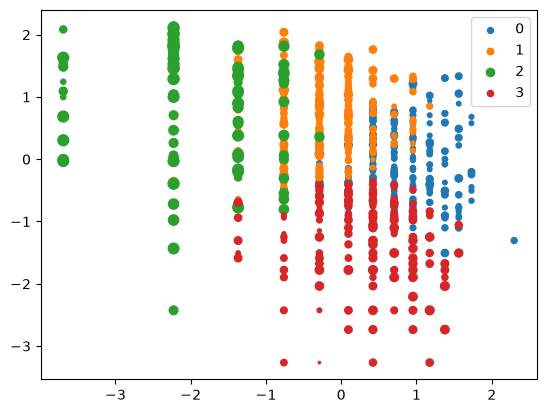

In [24]:
for i in np.unique(cat):
    rfm_tmp = rfm_scaled[cat == i]
    s = rfm_tmp[:, 1] * 12
    s -= np.min(s)
    plt.scatter(rfm_tmp[:, 0], rfm_tmp[:, 2], s=s, label=i)
    plt.legend()
plt.show()


In [25]:
rfm["KMenas_Cluster"] = km_model.labels_

In [26]:
np.unique(cat, return_counts=True)

(array([0, 1, 2, 3], dtype=int32), array([250, 272,  90, 181]))

In [27]:
rfm["f_score"] = pd.qcut(rfm["frequency"], q=7, labels=range(1,8))
rfm["m_score"] = pd.qcut(rfm["monetary"], q=7, labels=range(1,8))
rfm["r_score"] = pd.qcut(rfm["recency"], q=7, labels=range(7,0,-1))
rfm["scores"] = (rfm["r_score"].astype(int).astype(str) + rfm["f_score"].astype(int).astype(str) + rfm["m_score"].astype(int).astype(str))

In [28]:
rfm

,frequency,monetary,recency,KMenas_Cluster,f_score,m_score,r_score,scores
customer_id,,,,,,,,
AA-10315,5,5563.560,185,1,2,7,2,227
AA-10375,9,1056.390,20,3,6,2,7,762
AA-10480,4,1790.512,260,1,1,3,2,213
AA-10645,6,5086.935,56,0,3,6,5,536
AB-10015,3,886.156,416,2,1,2,1,112
...,...,...,...,...,...,...,...,...
XP-21865,11,2374.658,44,0,7,4,5,574
YC-21895,5,5454.350,5,3,2,7,7,727
YS-21880,8,6720.444,10,3,5,7,7,757


In [29]:
def segment(row):

    r = int(row["r_score"])
    f = int(row["f_score"])
    m = int(row["m_score"])

    if r >= 6 and f >= 6 and m >= 6:
        return "Champions"

    elif r >= 5 and f >= 5:
        return "Loyal Customers"

    elif r >= 6 and f >= 3:
        return "Potential Loyalists"

    elif r <= 2 and f >= 5 and m >= 5:
        return "At Risk"

    elif r <= 2 and f <= 3 and m <= 3:
        return "Lost Customers"

    else:
        return "Need Attention"

In [30]:
rfm["segment"] = rfm.apply(segment, axis=1)
rfm

,frequency,monetary,recency,KMenas_Cluster,f_score,m_score,r_score,scores,segment
customer_id,,,,,,,,,
AA-10315,5,5563.560,185,1,2,7,2,227,Need Attention
AA-10375,9,1056.390,20,3,6,2,7,762,Loyal Customers
AA-10480,4,1790.512,260,1,1,3,2,213,Lost Customers
AA-10645,6,5086.935,56,0,3,6,5,536,Need Attention
AB-10015,3,886.156,416,2,1,2,1,112,Lost Customers
...,...,...,...,...,...,...,...,...,...
XP-21865,11,2374.658,44,0,7,4,5,574,Loyal Customers
YC-21895,5,5454.350,5,3,2,7,7,727,Need Attention
YS-21880,8,6720.444,10,3,5,7,7,757,Loyal Customers


In [31]:
rfm["segment"].value_counts()

segment
Need Attention         443
Lost Customers         118
Loyal Customers        102
Potential Loyalists     70
Champions               37
At Risk                 23
Name: count, dtype: int64

<Axes: xlabel='frequency', ylabel='recency'>

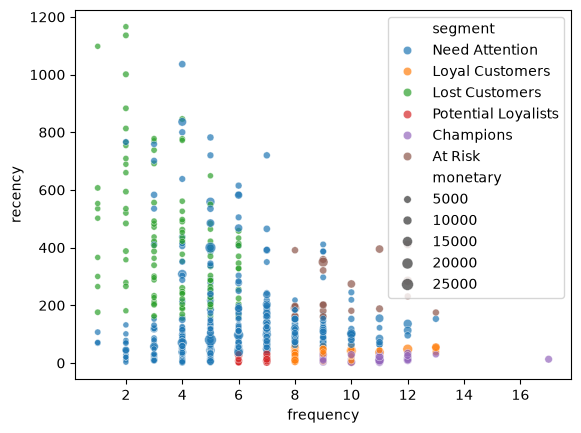

In [32]:
# sns.scatterplot(x=rfm["frequency"], y=["recency"], size=rfm["monetary"], hue=rfm["segment"])
sns.scatterplot(rfm, x='frequency', y='recency', size='monetary', hue='segment', alpha=0.7)

In [33]:
# df[df["customer_id"] == "CG-12520"]

customer_g0 = list(rfm[rfm["KMenas_Cluster"] == 0].index)
product_g0 = df.query('customer_id == @customer_g0').groupby(["product_id", "product_name"])["quantity"].sum().sort_values(ascending=False)
product_g0[:10]

product_id       product_name                                       
OFF-BI-10000545  GBC Ibimaster 500 Manual ProClick Binding System       43
FUR-CH-10002024  HON 5400 Series Task Chairs for Big and Tall           39
OFF-BI-10004728  Wilson Jones Turn Tabs Binder Tool for Ring Binders    38
FUR-TA-10002607  KI Conference Tables                                   38
OFF-LA-10001613  Avery File Folder Labels                               35
OFF-FA-10002280  Advantus Plastic Paper Clips                           34
OFF-ST-10002486  Eldon Shelf Savers Cubes and Bins                      33
OFF-ST-10001526  Iceberg Mobile Mega Data/Printer Cart                  33
FUR-FU-10003724  Westinghouse Clip-On Gooseneck Lamps                   33
OFF-ST-10000675  File Shuttle II and Handi-File, Black                  32
Name: quantity, dtype: int64

In [34]:
customer_g0 = list(rfm[rfm["KMenas_Cluster"] == 0].index)
product_g0 = df.query('customer_id == @customer_g0').groupby(["product_id", "product_name"])["revenue"].mean().sort_values(ascending=False)
product_g0[:10]

product_id       product_name                                                               
TEC-MA-10002412  Cisco TelePresence System EX90 Videoconferencing Unit                          22638.4800
TEC-CO-10004722  Canon imageCLASS 2200 Advanced Copier                                          12319.9648
OFF-SU-10000151  High Speed Automatic Electric Letter Opener                                     6550.1200
TEC-MA-10001127  HP Designjet T520 Inkjet Large Format Printer - 24" Color                       6124.9650
OFF-BI-10001120  Ibico EPK-21 Electric Binding System                                            5291.9720
TEC-MA-10001047  3D Systems Cube Printer, 2nd Generation, Magenta                                5199.9600
TEC-MA-10000984  Okidata MB760 Printer                                                           4476.8000
TEC-MA-10002927  Canon imageCLASS MF7460 Monochrome Digital Laser Multifunction Copier           3991.9800
OFF-BI-10003527  Fellowes PB500 Electric Punch Plas

In [35]:
customer_g3 = list(rfm[rfm["KMenas_Cluster"] == 3].index)
product_g3 = df.query('customer_id == @customer_g3').groupby(["product_id"])["quantity"].sum().sort_values(ascending=False)
product_g3[:10]

product_id
OFF-BI-10001922    32
OFF-BI-10003684    31
OFF-BI-10002026    30
OFF-ST-10000943    30
FUR-CH-10001146    28
TEC-AC-10002842    25
OFF-BI-10004970    25
OFF-AR-10004078    24
OFF-BI-10002982    24
OFF-PA-10000380    23
Name: quantity, dtype: int64

In [36]:
customer_g3 = list(rfm[rfm["KMenas_Cluster"] == 3].index)
revenuewise_product_g3 = df.query('customer_id == @customer_g3').groupby(["product_name"])["revenue"].mean().sort_values(ascending=False)
revenuewise_product_g3[:10]

product_name
Canon PC1060 Personal Laser Copier                        4899.930
Cubify CubeX 3D Printer Double Head Print                 4799.984
GBC DocuBind P400 Electric Binding System                 3810.772
Samsung Galaxy S4 Active                                  3499.930
Canon PC940 Copier                                        3149.930
Smead Adjustable Mobile File Trolley with Lockable Top    2934.330
Balt Solid Wood Round Tables                              2678.940
Lexmark MX611dhe Monochrome Laser Printer                 2549.985
Samsung Galaxy Mega 6.3                                   2435.942
GBC DocuBind 200 Manual Binding Machine                   2357.488
Name: revenue, dtype: float64

In [37]:
revenuewise_product_g3[-10:]

product_name
Avery Reinforcements for Hole-Punch Pages                         2.574000
Avery 497                                                         2.464000
Angle-D Ring Binders                                              2.461500
Storex Flexible Poly Binders with Double Pockets                  2.376000
Maxell 4.7GB DVD+R 5/Pack                                         2.376000
Pressboard Covers with Storage Hooks, 9 1/2" x 11", Light Blue    2.291333
Heavy-Duty E-Z-D Binders                                          2.182000
Computer Printout Index Tabs                                      1.680000
Avery Durable Slant Ring Binders, No Labels                       1.592000
Hoover Commercial Lightweight Upright Vacuum                      1.392000
Name: revenue, dtype: float64

In [38]:
customer_g3 = list(rfm[rfm["KMenas_Cluster"] == 3].index)
profitwise_product_g3 = df.query('customer_id == @customer_g3').groupby(["product_id", "product_name", "customer_name"])["profit"].mean().sort_values(ascending=False)
profitwise_product_g3[:10]

product_id       product_name                                                        customer_name   
OFF-BI-10004995  GBC DocuBind P400 Electric Binding System                           Andy Reiter         2504.2216
TEC-CO-10003763  Canon PC1060 Personal Laser Copier                                  Harry Marie         2302.9671
TEC-CO-10001766  Canon PC940 Copier                                                  Fred Hopkins        1480.4671
TEC-CO-10001449  Hewlett Packard LaserJet 3310 Copier                                Robert Marley       1007.9832
OFF-BI-10003925  Fellowes PB300 Plastic Comb Binding Machine                         Yana Sorensen        942.8157
TEC-PH-10000730  Samsung Galaxy S4 Active                                            Kristen Hastings     909.9818
OFF-BI-10004390  GBC DocuBind 200 Manual Binding Machine                             Erica Smith          884.0580
OFF-BI-10001359  GBC DocuBind TL300 Electric Binding System                          Amy Cox 

In [39]:
profitwise_product_g3[-10:]

product_id       product_name                                                                 customer_name   
FUR-TA-10001889  Bush Advantage Collection Racetrack Conference Table                         Michael Moore       -373.3048
FUR-TA-10000577  Bretford CR4500 Series Slim Rectangular Table                                Sean O'Donnell      -383.0310
FUR-BO-10001972  O'Sullivan 4-Shelf Bookcase in Odessa Pine                                   Juliana Krohn       -384.7164
FUR-TA-10004289  BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables            Darrin Van Huff     -420.0000
OFF-BI-10003650  GBC DocuBind 300 Electric Binding Machine                                    Giulietta Weimer    -462.8624
OFF-BI-10004584  GBC ProClick 150 Presentation Binding System                                 Michael Kennedy     -729.9138
OFF-AP-10002534  3.6 Cubic Foot Counter Height Office Refrigerator                            Joy Smith           -766.0120
OFF-BI-10003527  Fell

In [40]:
rfm["AOV"] = rfm["monetary"] / rfm["frequency"]             # revenue / order count
rfm

,frequency,monetary,recency,KMenas_Cluster,f_score,m_score,r_score,scores,segment,AOV
customer_id,,,,,,,,,,
AA-10315,5,5563.560,185,1,2,7,2,227,Need Attention,1112.712000
AA-10375,9,1056.390,20,3,6,2,7,762,Loyal Customers,117.376667
AA-10480,4,1790.512,260,1,1,3,2,213,Lost Customers,447.628000
AA-10645,6,5086.935,56,0,3,6,5,536,Need Attention,847.822500
AB-10015,3,886.156,416,2,1,2,1,112,Lost Customers,295.385333
...,...,...,...,...,...,...,...,...,...,...
XP-21865,11,2374.658,44,0,7,4,5,574,Loyal Customers,215.878000
YC-21895,5,5454.350,5,3,2,7,7,727,Need Attention,1090.870000
YS-21880,8,6720.444,10,3,5,7,7,757,Loyal Customers,840.055500


In [41]:
product_diversity = (df.groupby("customer_id")["product_id"].nunique())
product_diversity

customer_id
AA-10315    11
AA-10375    15
AA-10480    12
AA-10645    18
AB-10015     6
            ..
XP-21865    28
YC-21895     8
YS-21880    11
ZC-21910    31
ZD-21925     9
Name: product_id, Length: 793, dtype: int64

In [42]:
category_diversity = (df.groupby("customer_id")["category"].nunique())
category_diversity

customer_id
AA-10315    3
AA-10375    3
AA-10480    3
AA-10645    3
AB-10015    3
           ..
XP-21865    3
YC-21895    3
YS-21880    3
ZC-21910    3
ZD-21925    3
Name: category, Length: 793, dtype: int64

In [43]:
df["cohort_month"] = (df.groupby("customer_id")["order_date"].transform("min").dt.to_period("M"))
df["cohort_index"] = ((df["order_month"].dt.year - df["cohort_month"].dt.year) * 12 +(df["order_month"].dt.month - df["cohort_month"].dt.month))

In [44]:
df[:10]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,revenue,quantity,discount,profit,order_year,order_month,order_month_name,order_day,cohort_month,cohort_index
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,2016-11,November,Tuesday,2015-10,13
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,2016-11,November,Tuesday,2015-10,13
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,2016-06,June,Sunday,2016-06,0
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,2015-10,October,Sunday,2015-10,0
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,2015-10,October,Sunday,2015-10,0
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694,2014,2014-06,June,Monday,2014-06,0
6,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656,2014,2014-06,June,Monday,2014-06,0
7,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152,2014,2014-06,June,Monday,2014-06,0
8,9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825,2014,2014-06,June,Monday,2014-06,0
9,10,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700,2014,2014-06,June,Monday,2014-06,0


In [45]:
cohort_data = (df.groupby(["order_month", "cohort_month", "cohort_index"])["customer_id"].nunique().reset_index())
cohort_data

,order_month,cohort_month,cohort_index,customer_id
0,2014-01,2014-01,0,32
1,2014-02,2014-01,1,3
2,2014-02,2014-02,0,24
3,2014-03,2014-02,1,4
4,2014-03,2014-03,0,65
...,...,...,...,...
889,2017-12,2016-10,14,1
890,2017-12,2016-11,13,3
891,2017-12,2016-12,12,1
892,2017-12,2017-06,6,1


In [46]:
cohort_table = cohort_data.pivot_table(index="cohort_month", columns="cohort_index", values="customer_id")
cohort_table 

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47
cohort_month,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-01,32.0,3.0,NaN,2.0,2.0,NaN,2.0,4.0,5.0,3.0,7.0,5.0,3.0,NaN,3.0,3.0,3.0,4.0,3.0,2.0,4.0,NaN,6.0,5.0,2.0,1.0,5.0,4.0,3.0,5.0,1.0,1.0,11.0,2.0,9.0,6.0,5.0,1.0,6.0,4.0,5.0,4.0,1.0,2.0,9.0,9.0,10.0,6.0
2014-02,24.0,4.0,2.0,1.0,NaN,2.0,2.0,3.0,3.0,4.0,4.0,1.0,NaN,2.0,2.0,2.0,2.0,3.0,NaN,6.0,2.0,3.0,2.0,NaN,3.0,1.0,1.0,4.0,NaN,3.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0,2.0,2.0,5.0,3.0,3.0,4.0,6.0,6.0,3.0,NaN
2014-03,65.0,4.0,2.0,8.0,7.0,NaN,7.0,5.0,8.0,6.0,1.0,2.0,6.0,3.0,5.0,5.0,3.0,5.0,9.0,11.0,13.0,12.0,4.0,4.0,6.0,8.0,8.0,6.0,9.0,5.0,13.0,8.0,13.0,10.0,2.0,6.0,6.0,12.0,13.0,10.0,12.0,6.0,19.0,8.0,18.0,16.0,NaN,NaN
2014-04,56.0,6.0,2.0,4.0,3.0,8.0,6.0,9.0,8.0,1.0,4.0,5.0,8.0,10.0,6.0,5.0,6.0,9.0,3.0,14.0,11.0,3.0,2.0,7.0,5.0,8.0,9.0,8.0,5.0,14.0,6.0,14.0,15.0,4.0,3.0,14.0,3.0,11.0,5.0,7.0,8.0,15.0,8.0,14.0,14.0,NaN,NaN,NaN
2014-05,56.0,5.0,5.0,4.0,10.0,2.0,12.0,10.0,4.0,3.0,4.0,7.0,2.0,5.0,2.0,5.0,8.0,6.0,11.0,8.0,5.0,2.0,3.0,7.0,7.0,5.0,5.0,4.0,11.0,8.0,13.0,13.0,4.0,3.0,3.0,5.0,4.0,11.0,7.0,6.0,16.0,7.0,17.0,9.0,NaN,NaN,NaN,NaN
2014-06,48.0,1.0,2.0,4.0,2.0,9.0,8.0,1.0,4.0,6.0,5.0,5.0,3.0,4.0,7.0,5.0,7.0,16.0,9.0,3.0,2.0,9.0,5.0,4.0,5.0,4.0,2.0,11.0,10.0,7.0,14.0,3.0,3.0,4.0,6.0,9.0,9.0,5.0,3.0,13.0,7.0,14.0,11.0,NaN,NaN,NaN,NaN,NaN
2014-07,44.0,6.0,5.0,NaN,5.0,8.0,2.0,NaN,8.0,2.0,7.0,7.0,5.0,NaN,5.0,4.0,6.0,7.0,2.0,2.0,4.0,5.0,6.0,6.0,4.0,9.0,7.0,6.0,11.0,10.0,3.0,7.0,4.0,6.0,7.0,9.0,4.0,6.0,11.0,10.0,13.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN
2014-08,49.0,8.0,3.0,11.0,5.0,3.0,4.0,2.0,4.0,3.0,5.0,6.0,2.0,9.0,6.0,8.0,13.0,2.0,1.0,4.0,3.0,7.0,6.0,7.0,9.0,15.0,5.0,11.0,11.0,2.0,4.0,3.0,8.0,7.0,7.0,9.0,8.0,9.0,12.0,11.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09,68.0,9.0,9.0,11.0,1.0,2.0,9.0,10.0,9.0,2.0,6.0,8.0,12.0,6.0,13.0,15.0,2.0,5.0,9.0,5.0,9.0,8.0,7.0,4.0,12.0,3.0,15.0,13.0,3.0,2.0,9.0,9.0,8.0,11.0,13.0,9.0,15.0,10.0,16.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
retention = cohort_table.divide(cohort_table.iloc[:,0], axis=0)
retention * 100

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47
cohort_month,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-01,100.0,9.375000,NaN,6.250000,6.250000,NaN,6.250000,12.500000,15.625000,9.375000,21.875000,15.625000,9.375000,NaN,9.375000,9.375000,9.375000,12.500000,9.375000,6.250000,12.500000,NaN,18.750000,15.625000,6.250000,3.125000,15.625000,12.500000,9.375000,15.625000,3.125000,3.125000,34.375000,6.250000,28.125000,18.750000,15.625000,3.125000,18.750000,12.500000,15.625000,12.500000,3.125000,6.250000,28.125000,28.125000,31.25,18.75
2014-02,100.0,16.666667,8.333333,4.166667,NaN,8.333333,8.333333,12.500000,12.500000,16.666667,16.666667,4.166667,NaN,8.333333,8.333333,8.333333,8.333333,12.500000,NaN,25.000000,8.333333,12.500000,8.333333,NaN,12.500000,4.166667,4.166667,16.666667,NaN,12.500000,16.666667,16.666667,16.666667,16.666667,16.666667,16.666667,12.500000,16.666667,8.333333,8.333333,20.833333,12.500000,12.500000,16.666667,25.000000,25.000000,12.50,NaN
2014-03,100.0,6.153846,3.076923,12.307692,10.769231,NaN,10.769231,7.692308,12.307692,9.230769,1.538462,3.076923,9.230769,4.615385,7.692308,7.692308,4.615385,7.692308,13.846154,16.923077,20.000000,18.461538,6.153846,6.153846,9.230769,12.307692,12.307692,9.230769,13.846154,7.692308,20.000000,12.307692,20.000000,15.384615,3.076923,9.230769,9.230769,18.461538,20.000000,15.384615,18.461538,9.230769,29.230769,12.307692,27.692308,24.615385,NaN,NaN
2014-04,100.0,10.714286,3.571429,7.142857,5.357143,14.285714,10.714286,16.071429,14.285714,1.785714,7.142857,8.928571,14.285714,17.857143,10.714286,8.928571,10.714286,16.071429,5.357143,25.000000,19.642857,5.357143,3.571429,12.500000,8.928571,14.285714,16.071429,14.285714,8.928571,25.000000,10.714286,25.000000,26.785714,7.142857,5.357143,25.000000,5.357143,19.642857,8.928571,12.500000,14.285714,26.785714,14.285714,25.000000,25.000000,NaN,NaN,NaN
2014-05,100.0,8.928571,8.928571,7.142857,17.857143,3.571429,21.428571,17.857143,7.142857,5.357143,7.142857,12.500000,3.571429,8.928571,3.571429,8.928571,14.285714,10.714286,19.642857,14.285714,8.928571,3.571429,5.357143,12.500000,12.500000,8.928571,8.928571,7.142857,19.642857,14.285714,23.214286,23.214286,7.142857,5.357143,5.357143,8.928571,7.142857,19.642857,12.500000,10.714286,28.571429,12.500000,30.357143,16.071429,NaN,NaN,NaN,NaN
2014-06,100.0,2.083333,4.166667,8.333333,4.166667,18.750000,16.666667,2.083333,8.333333,12.500000,10.416667,10.416667,6.250000,8.333333,14.583333,10.416667,14.583333,33.333333,18.750000,6.250000,4.166667,18.750000,10.416667,8.333333,10.416667,8.333333,4.166667,22.916667,20.833333,14.583333,29.166667,6.250000,6.250000,8.333333,12.500000,18.750000,18.750000,10.416667,6.250000,27.083333,14.583333,29.166667,22.916667,NaN,NaN,NaN,NaN,NaN
2014-07,100.0,13.636364,11.363636,NaN,11.363636,18.181818,4.545455,NaN,18.181818,4.545455,15.909091,15.909091,11.363636,NaN,11.363636,9.090909,13.636364,15.909091,4.545455,4.545455,9.090909,11.363636,13.636364,13.636364,9.090909,20.454545,15.909091,13.636364,25.000000,22.727273,6.818182,15.909091,9.090909,13.636364,15.909091,20.454545,9.090909,13.636364,25.000000,22.727273,29.545455,20.454545,NaN,NaN,NaN,NaN,NaN,NaN
2014-08,100.0,16.326531,6.122449,22.448980,10.204082,6.122449,8.163265,4.081633,8.163265,6.122449,10.204082,12.244898,4.081633,18.367347,12.244898,16.326531,26.530612,4.081633,2.040816,8.163265,6.122449,14.285714,12.244898,14.285714,18.367347,30.612245,10.204082,22.448980,22.448980,4.081633,8.163265,6.122449,16.326531,14.285714,14.285714,18.367347,16.326531,18.367347,24.489796,22.448980,20.408163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09,100.0,13.235294,13.235294,16.176471,1.470588,2.941176,13.235294,14.705882,13.235294,2.941176,8.823529,11.764706,17.647059,8.823529,19.117647,22.058824,2.941176,7.352941,13.235294,7.352941,13.235294,11.764706,10.294118,5.882353,17.647059,4.411765,22.058824,19.117647,4.411765,2.941176,13.235294,13.235294,1

In [48]:
dbscan = DBSCAN(eps=0.9, min_samples=1)
db = dbscan.fit_predict(rfm_scaled)
np.unique(dbscan.labels_)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [49]:
silhouette = silhouette_score(rfm_scaled, dbscan.labels_)
silhouette

0.2382888477884902

In [50]:
silhouette_scores = silhouette_samples(rfm_scaled, dbscan.labels_)
pd.Series(silhouette_scores).groupby(dbscan.labels_).describe()

,count,mean,std,min,25%,50%,75%,max
0,776.0,0.235767,0.266377,-0.747950,0.142842,0.331626,0.431388,0.509668
1,4.0,0.484547,0.181421,0.219456,0.456336,0.544399,0.572610,0.629932
2,2.0,0.789295,0.013148,0.779997,0.784646,0.789295,0.793943,0.798592
3,1.0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
4,4.0,0.622753,0.195803,0.330683,0.603260,0.707873,0.727366,0.744582
5,1.0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
6,1.0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
7,1.0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
8,1.0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
9,1.0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000


In [51]:
rfm["dbscan"] = dbscan.labels_

In [52]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, n_jobs=-1)
pred = lof.fit_predict(rfm_scaled)
np.unique(pred, return_counts=True)

(array([-1,  1]), array([ 40, 753]))

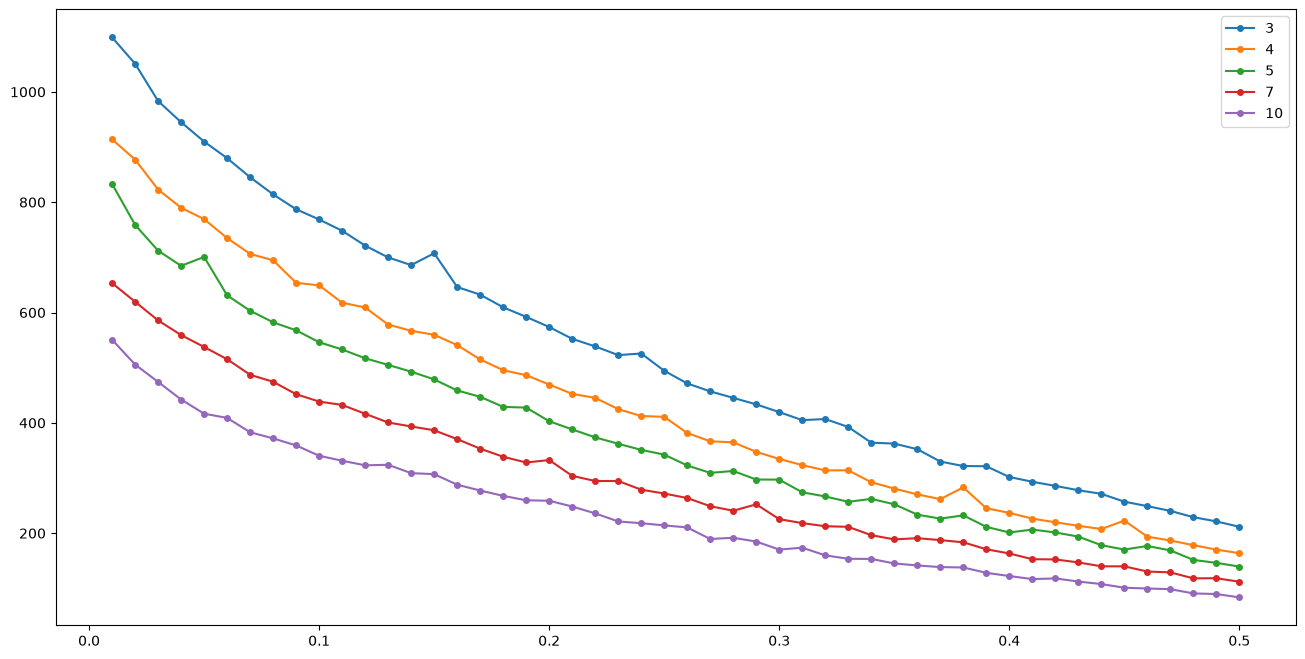

In [53]:
plt.figure(figsize=(16, 8))

clusters = [3, 4, 5, 7, 10]
inertia = {c: [] for c in clusters}
span = np.linspace(0.01, 0.5, 50)
for s in span:
    pred = LocalOutlierFactor(n_neighbors=20, contamination=s, n_jobs=-1).fit_predict(rfm_scaled)
    for cluster in clusters:
        inertia[cluster].append(KMeans(n_clusters=cluster, init="k-means++").fit(rfm_scaled[pred == 1]).inertia_)

for cluster, inertia_ in inertia.items():
    plt.plot(span, inertia_, marker='o', ms=4, label=cluster)

plt.legend()
plt.show()